# Spotify Statistical Data Visualisation


Dataset used: **Kaggle** – https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data

Contains **89,741** tracks from **125** different music genres. Each track has the following columns:

- `track_name` – track name
- `popularity` – track popularity score
- `duration_ms` – duration in milliseconds
- `explicit` – whether the track contains explicit content
- `danceability` – describes how suitable a track is for dancing based on musical elements (tempo, rhythm stability). Ranges from 0.0 (least danceable) to 1.0 (most danceable).
- `energy` – measure of intensity and activity (0.0–1.0). High value = fast, loud, dynamic track (e.g. death metal); low value = calm compositions (e.g. Bach prelude).
- `key` – musical key of the track, integer 0–11 (0 = C, 1 = C♯/D♭, …, 11 = B). Value -1 means no key detected.
- `loudness` – overall loudness in decibels (average). Typical range: -60 dB (quiet) to 0 dB (loud).
- `speechiness` – presence of spoken words. >0.66 = mostly speech, 0.33–0.66 = mix of speech and music, <0.33 = purely musical.
- `acousticness` – probability that the track is acoustic. 1.0 = highly acoustic, 0.0 = no acoustic characteristics.
- `instrumentalness` – predicts whether a track is instrumental. Values >0.5 suggest no vocals; the higher the value, the greater the confidence.
- `liveness` – detects live recording elements. Value >0.8 indicates high probability of a live audience recording.
- `valence` – musical positivity. 0.0 = very sad/negative-sounding, 1.0 = happy, euphoric.
- `tempo` – track tempo in BPM (beats per minute).
- `track_genre` – music genre of the track.
- `mode` – tonality mode: 1 = major, 0 = minor.
- `time_signature` – time signature, number of beats per bar (range: 3 to 7).


**Instructions for use with a different dataset:**

1. Download the dataset from Kaggle and place the CSV file in the same directory as this notebook.
2. In the `Loading Data from CSV File` section, change the file name to the downloaded file's name.


## Import

In [23]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider, Button, HBox, VBox, Output, Label

## Loading Data from CSV File


In [24]:
with open("dataset.csv", newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    all_tracks = list(reader)

df = pd.DataFrame(all_tracks)

df = df.drop(columns=[''])

df.head(5)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,1.01e-06,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.42,0.166,1,-17.235,1,0.0763,0.924,5.56e-06,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.21,0.0,0.117,0.12,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.905,7.07e-05,0.132,0.143,181.74,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.0526,0.469,0.0,0.0829,0.167,119.949,4,acoustic


## Audio Feature Distribution – KDE Plot

Kernel Density Estimation (KDE) is a non-parametric method for estimating the probability density function of a random variable. Unlike a histogram, it produces a smooth curve and can represent both the shape of the distribution and its density. The area under the KDE curve equals 1.

The chart shows the density distribution of the selected audio feature across all tracks in the dataset.


In [ ]:
# List of features to analyse
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

# Function to draw KDE plot
def plot_kde(feature):
    data = pd.to_numeric(df[feature], errors='coerce').dropna()

    fig, ax = plt.subplots(figsize=(10, 4))
    data.plot.kde(ax=ax, color="steelblue", linewidth=2)
    plt.title(f"Density distribution: {feature.capitalize()}", fontsize=14)
    plt.xlabel(feature.capitalize(), fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.tight_layout()
    plt.show()

# Feature selection
feature_widget = widgets.Dropdown(
    options=features,
    value=features[0],
    description='Feature:',
    style={'description_width': 'initial'}
)

widgets.interact(plot_kde, feature=feature_widget)

interactive(children=(Dropdown(description='Feature:', options=('danceability', 'energy', 'loudness', 'speechi…

<function __main__.plot_kde(feature)>

## Popularity vs Audio Features – Hexbin Plot

A hexbin plot is a 2D histogram that divides the data space into hexagonal cells and counts the number of data points falling into each cell. It is especially useful for visualising large datasets where individual scatter points would overlap. The colour indicates the number of tracks per cell.

The chart shows the relationship between the selected audio feature and track popularity. Each hexagonal cell represents a group of tracks with similar feature values and similar popularity levels.

- **X axis** – selected audio feature value (e.g. energy, danceability, tempo)
- **Y axis** – track popularity (range 0–100)
- **Colour** – number of tracks in the cell (the darker/warmer the colour, the more tracks)


In [ ]:
# List of features to analyse
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

def plot_hexbin(feature):
    # Data preparation
    dfc = df[[feature, "popularity"]].copy()
    # Convert and clean columns
    dfc[feature] = pd.to_numeric(dfc[feature], errors='coerce')
    dfc["popularity"] = pd.to_numeric(dfc["popularity"], errors='coerce')
    # Remove invalid popularity values
    dfc = dfc.dropna()
    dfc = dfc[dfc["popularity"] > 0]

    fig, ax = plt.subplots(figsize=(10, 5))
    # Hexbin plot
    hb = ax.hexbin(dfc[feature], dfc["popularity"], gridsize=40, cmap="YlOrRd", mincnt=1)
    cbar = plt.colorbar(hb, ax=ax)
    cbar.set_label("Number of tracks", fontsize=10)
    plt.yticks(np.arange(0, 101, 10))
    plt.title(f"{feature.capitalize()} vs track popularity", fontsize=14)
    plt.xlabel(f"{feature.capitalize()} [value]", fontsize=12)
    plt.ylabel("Popularity [1 - 100]", fontsize=12)
    plt.tight_layout()
    plt.show()

# Interactive widget
feature_widget = widgets.Dropdown(
    options=features,
    value=features[0],
    description='Feature:',
    style={'description_width': 'initial'}
)

widgets.interact(plot_hexbin, feature=feature_widget)


interactive(children=(Dropdown(description='Feature:', options=('danceability', 'energy', 'loudness', 'speechi…

<function __main__.plot_hexbin(feature)>

## Popularity vs Audio Features – Violin Plot

A violin plot is a chart that combines a box plot with a KDE density curve. It shows the distribution of a continuous variable across categories or groups. The wider the "violin" at a given value, the more data points concentrate there.

The chart shows the relationship between the selected audio feature and track popularity. The feature is divided into equal-width bins, and for each bin a violin is drawn showing the distribution of popularity values.

- **X axis** – bins (ranges) of the selected audio feature value
- **Y axis** – track popularity (range 1–100)


In [14]:
# List of features to analyse
features = ["danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

def plot_violin(feature):
    dfv = df[[feature, "popularity"]].copy()
    # Convert column to float
    dfv[feature] = pd.to_numeric(dfv[feature], errors='coerce')
    dfv["popularity"] = pd.to_numeric(dfv["popularity"], errors='coerce')
    # Remove missing values
    dfv = dfv.dropna()
    dfv = dfv[dfv["popularity"] > 0]

    # Create bins
    dfv["bin"] = pd.cut(dfv[feature], bins=10)
    dfv["bin"] = dfv["bin"].astype(str)

    # Draw plot
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.violinplot(data=dfv, x="bin", y="popularity", ax=ax, inner="box", color="steelblue")
    plt.title(f"Popularity distribution by {feature} value", fontsize=14)
    plt.xlabel(f"{feature.capitalize()} (bins)", fontsize=12)
    plt.ylabel("Popularity [1 - 100]", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Interactive widget
feature_widget = widgets.Dropdown(
    options=features,
    value=features[0],
    description='Feature:',
    style={'description_width': 'initial'}
)

widgets.interact(plot_violin, feature=feature_widget)


interactive(children=(Dropdown(description='Feature:', options=('danceability', 'energy', 'loudness', 'speechi…

<function __main__.plot_violin(feature)>

## Track Duration vs Number of Tracks – Scatter Plot


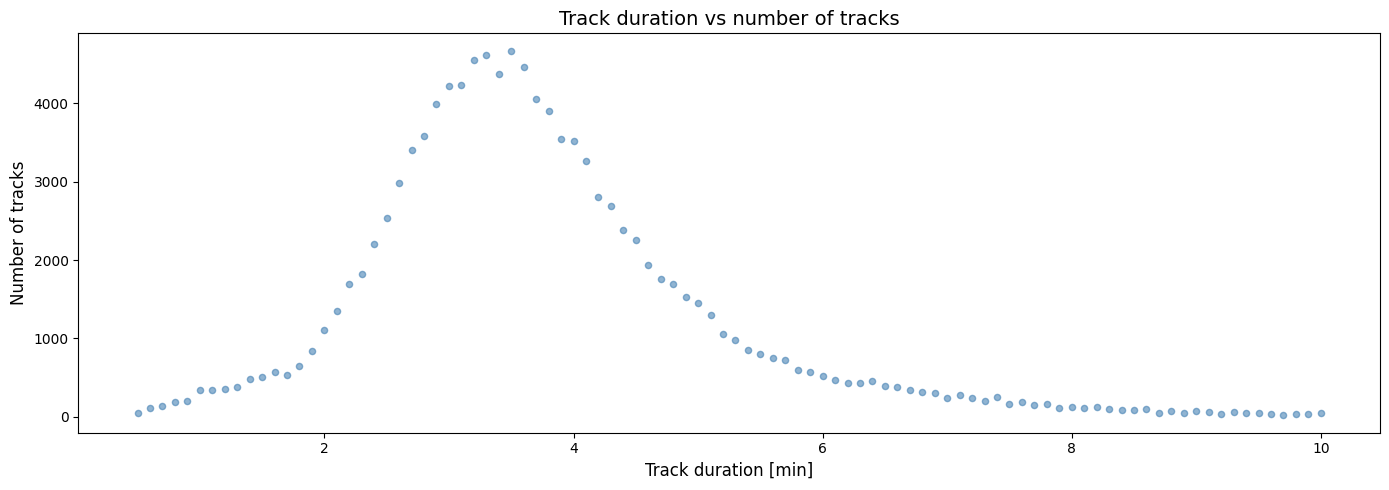

In [15]:
dfs = df[["duration_ms", "track_name"]].copy()
# Clean data
dfs["duration_ms"] = pd.to_numeric(dfs["duration_ms"], errors='coerce')
dfs = dfs.dropna(subset=["duration_ms"])
# Convert to minutes
dfs["duration_min"] = (dfs["duration_ms"] / 60000).round(1)
# Group with rounding
grouped = dfs.groupby("duration_min").size().reset_index(name="count")
grouped = grouped[(grouped["duration_min"] >= 0.5) & (grouped["duration_min"] <= 10)]

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(grouped["duration_min"], grouped["count"], alpha=0.6, s=20, color="steelblue")
plt.title("Track duration vs number of tracks", fontsize=14)
plt.xlabel("Track duration [min]", fontsize=12)
plt.ylabel("Number of tracks", fontsize=12)
plt.tight_layout()
plt.show()


## Track Duration vs Popularity – Hexbin Plot


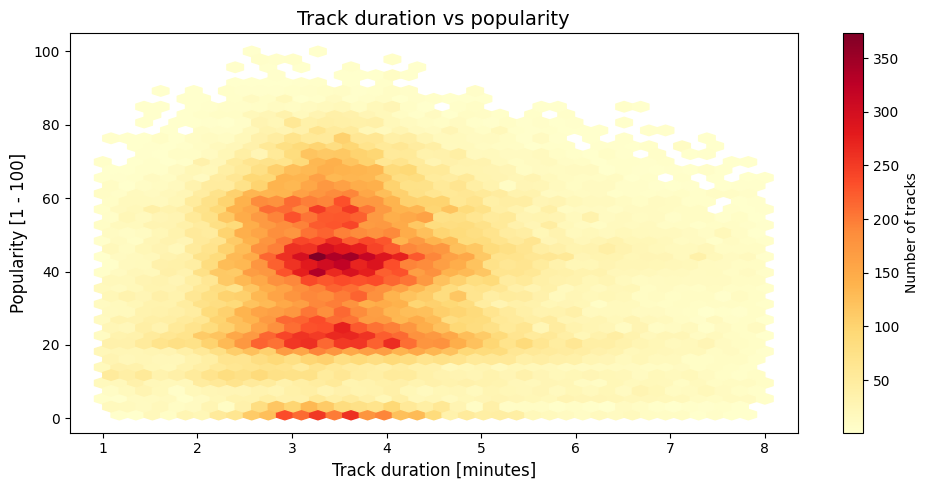

In [16]:
dfh = df[["duration_ms", "popularity"]].copy()
# Clean data
dfh["duration_ms"] = pd.to_numeric(dfh["duration_ms"], errors='coerce')
dfh["popularity"] = pd.to_numeric(dfh["popularity"], errors='coerce')
dfh = dfh.dropna()
dfh = dfh[dfh["popularity"] > 0]
# Convert to minutes
dfh["duration_min"] = dfh["duration_ms"] / 60000
# Limit range to 1-8 minutes
dfh = dfh[(dfh["duration_min"] >= 1) & (dfh["duration_min"] <= 8)]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
hb = ax.hexbin(dfh["duration_min"], dfh["popularity"], gridsize=40, cmap="YlOrRd", mincnt=1)
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label("Number of tracks", fontsize=10)
plt.title("Track duration vs popularity", fontsize=14)
plt.xlabel("Track duration [minutes]", fontsize=12)
plt.ylabel("Popularity [1 - 100]", fontsize=12)
plt.tight_layout()
plt.show()


## Most Popular Genres – Bar Chart


In [17]:
def plot_genres(top_n=20):
    dfl = df[["track_genre", "popularity"]].copy()
    dfl["popularity"] = pd.to_numeric(dfl["popularity"], errors='coerce')
    dfl = dfl.dropna(subset=["popularity"])

    # Count tracks per genre
    genre_counts = dfl["track_genre"].value_counts()
    # Genres with < 100 tracks are grouped as "other"
    rare_genres = genre_counts[genre_counts < 100].index
    # Replace rare genres with "other"
    dfl["genre_grouped"] = dfl["track_genre"].apply(lambda x: "other" if x in rare_genres else x)

    # Average popularity per grouped genre
    genre_popularity = dfl.groupby("genre_grouped")["popularity"].mean().sort_values(ascending=False)
    top_genres = genre_popularity.head(top_n)

    # Plot
    fig, ax = plt.subplots(figsize=(10, top_n // 3 + 3))
    top_genres.sort_values().plot.barh(ax=ax, color="steelblue")
    plt.title(f"Average popularity – top {top_n} genres (others grouped as 'other')", fontsize=14)
    plt.xlabel("Average popularity [0–100]", fontsize=12)
    plt.ylabel("Genre", fontsize=12)
    plt.tight_layout()
    plt.show()

# Interactive slider
top_n_widget = widgets.IntSlider(value=20, min=5, max=50, step=5, description='Top N:')
widgets.interact(plot_genres, top_n=top_n_widget)


interactive(children=(IntSlider(value=20, description='Top N:', max=50, min=5, step=5), Output()), _dom_classe…

<function __main__.plot_genres(top_n=20)>

## Musical Keys by Genre – Heatmap


In [18]:
# Data preparation
dfk = df[["track_genre", "key"]].copy()
dfk["key"] = pd.to_numeric(dfk["key"], errors='coerce')
dfk = dfk.dropna()
dfk = dfk[dfk["key"] >= 0]

pivot = dfk.groupby(["track_genre", "key"]).size().unstack(fill_value=0)

# Labels
key_labels = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
pivot.columns = [key_labels[k] for k in pivot.columns]

# Pagination parameters
page_size = 20
current_page = [0]
max_page = (len(pivot) - 1) // page_size

# Interface
btn_prev = Button(description="⏮ Previous", button_style='info')
btn_next = Button(description="Next ⏭", button_style='info')
label = Label(value=f"Page {current_page[0] + 1} of {max_page + 1}")
output = Output()

def draw_page():
    output.clear_output(wait=True)
    start = current_page[0] * page_size
    end = start + page_size
    chunk = pivot.iloc[start:end]
    with output:
        # Heatmap plot
        fig, ax = plt.subplots(figsize=(14, max(4, len(chunk) * 0.45)))
        sns.heatmap(chunk, annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.3)
        plt.title(f"Track keys – genres {start + 1}–{min(end, len(pivot))} of {len(pivot)}", fontsize=14)
        plt.xlabel("Key", fontsize=12)
        plt.ylabel("Genre", fontsize=12)
        plt.tight_layout()
        plt.show()
    label.value = f"Page {current_page[0] + 1} of {max_page + 1}"

def on_prev(b):
    if current_page[0] > 0:
        current_page[0] -= 1
        draw_page()

def on_next(b):
    if current_page[0] < max_page:
        current_page[0] += 1
        draw_page()

btn_prev.on_click(on_prev)
btn_next.on_click(on_next)

display(HBox([btn_prev, label, btn_next]), output)
draw_page()


Output()

## Audio Feature Correlation


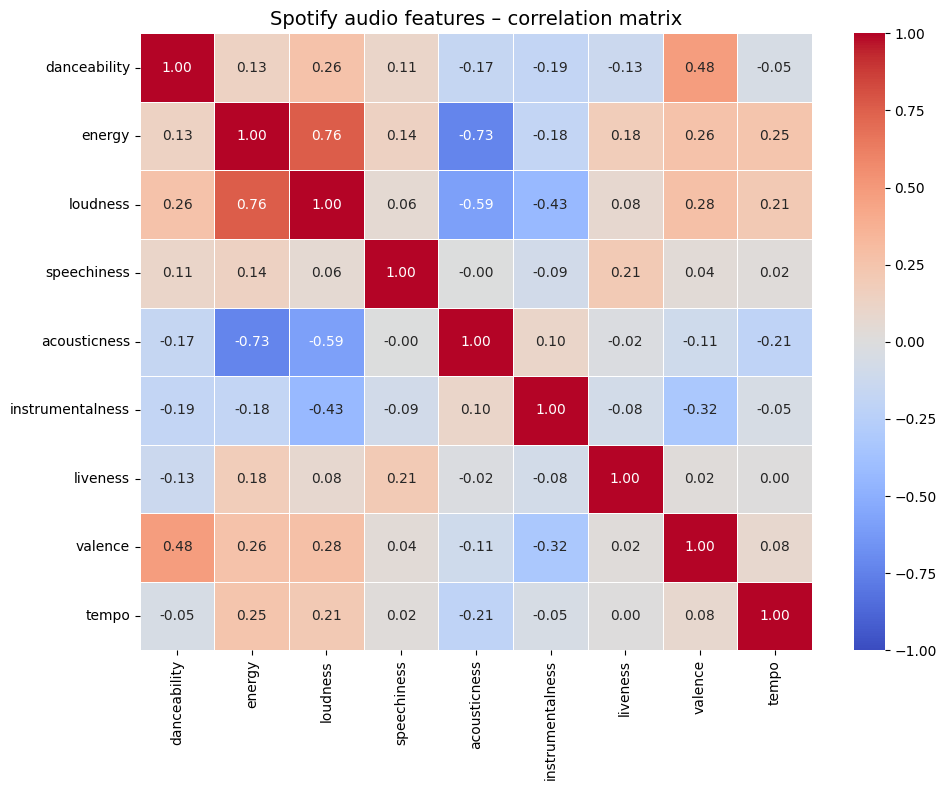

In [19]:
# List of audio features
audio_features = ["danceability", "energy", "loudness", "speechiness",
                  "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

dfc = df[audio_features].copy()
# Convert to float
for col in audio_features:
    dfc[col] = pd.to_numeric(dfc[col], errors='coerce')
dfc = dfc.dropna()

# Correlation matrix
corr = dfc.corr()

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Spotify audio features – correlation matrix", fontsize=14)
plt.tight_layout()
plt.show()


## Popularity vs Explicit Content


C:\Users\Tori\AppData\Local\Temp\ipykernel_15624\3908507288.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfe, x="explicit_label", y="popularity", ax=ax, palette="Set2")


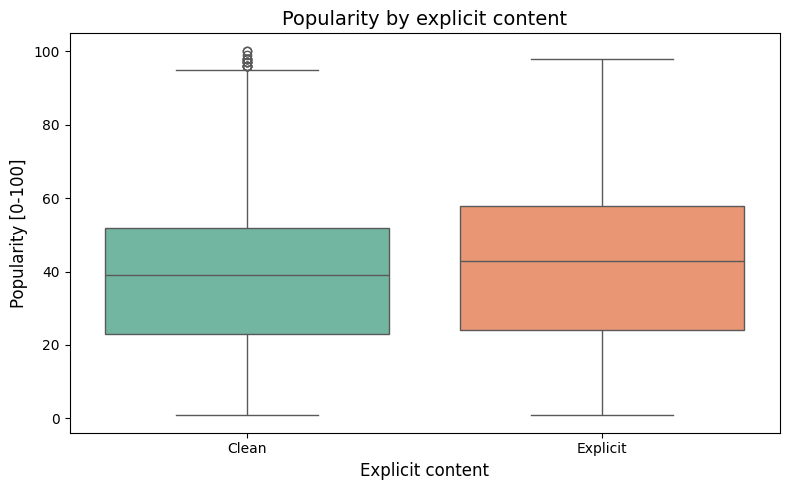

In [20]:
dfe = df[["explicit", "popularity"]].copy()
# Data preparation
dfe["popularity"] = pd.to_numeric(dfe["popularity"], errors='coerce')
dfe = dfe.dropna()
dfe = dfe[dfe["popularity"] > 0]

# Labels
dfe["explicit_label"] = dfe["explicit"].map({True: "Explicit", False: "Clean",
                                              1: "Explicit", 0: "Clean",
                                              "True": "Explicit", "False": "Clean"})

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=dfe, x="explicit_label", y="popularity", ax=ax, palette="Set2")
plt.title("Popularity by explicit content", fontsize=14)
plt.xlabel("Explicit content", fontsize=12)
plt.ylabel("Popularity [0-100]", fontsize=12)
plt.tight_layout()
plt.show()


## Number of Tracks by Mode


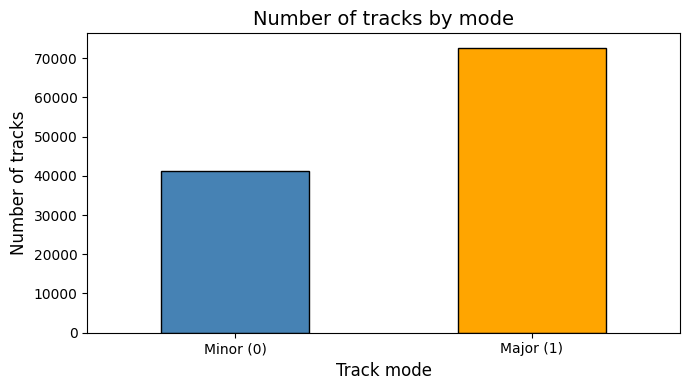

In [21]:
dfm = df[["mode", "track_name"]].copy()
# Data preparation
dfm["mode"] = pd.to_numeric(dfm["mode"], errors='coerce')
dfm = dfm.dropna(subset=["mode"])
dfm["mode"] = dfm["mode"].astype(int)

# Group and count tracks
mode_counts = dfm["mode"].value_counts().sort_index()
mode_labels = {0: "Minor (0)", 1: "Major (1)"}
mode_counts.index = [mode_labels.get(i, str(i)) for i in mode_counts.index]

# Bar plot
fig, ax = plt.subplots(figsize=(7, 4))
mode_counts.plot.bar(ax=ax, color=["steelblue", "orange"], edgecolor="black")
plt.title("Number of tracks by mode", fontsize=14)
plt.xlabel("Track mode", fontsize=12)
plt.ylabel("Number of tracks", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
